In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/life_satisfaction_canadian_survey_ml.csv")

df_ml.head()

,Total_active_time,Total_physical_act_time,Other_physical_act_time,Physical_vigorous_act_time,Marital_status__missing,Household__missing,Worked_job_business__missing,Edu_level__missing,Gen_health_state__missing,Life_satisfaction__missing,Mental_health_state__missing,Stress_level__missing,Work_stress__missing,Sense_belonging__missing,Weight_state__missing,BMI_12_17__missing,BMI_18_above__missing,Sleep_apnea__missing,High_BP__missing,Diabetic__missing,Fatigue_syndrome__missing,Mood_disorder__missing,Anxiety_disorder__missing,Respiratory_chronic_con__missing,Musculoskeletal_con__missing,Cardiovascular_con__missing,Health_utility_indx__missing,Pain_status__missing,Act_improve_health__missing,Fruit_veg_con__missing,Smoked__missing,Tobaco_use__missing,weekly_alcohol__missing,Cannabies_use__missing,Drug_use__missing,Total_active_time__missing,Total_physical_act_time__missing,Other_physical_act_time__missing,Physical_vigorous_act_time__missing,Work_hours__missing,working_status__missing,Aboriginal_identity__missing,Birth_country__missing,Immigrant__missing,Insurance_cover__missing,Food_security__missing,Income_source__missing,Total_income__missing,Health_region_ grouped_10912,Health_region_ grouped_10913,Health_region_ grouped_11900,Health_region_ grouped_12901,Health_region_ grouped_12902,Health_region_ grouped_12903,Health_region_ grouped_12904,Health_region_ grouped_13901,Health_region_ grouped_13902,Health_region_ grouped_13903,Health_region_ grouped_13904,Health_region_ grouped_13906,Health_region_ grouped_24901,Health_region_ grouped_24902,Health_region_ grouped_24903,Health_region_ grouped_24904,Health_region_ grouped_24905,Health_region_ grouped_24906,Health_region_ grouped_24907,Health_region_ grouped_24908,Health_region_ grouped_24909,Health_region_ grouped_24911,Health_region_ grouped_24912,Health_region_ grouped_24913,Health_region_ grouped_24914,Health_region_ grouped_24915,Health_region_ grouped_24916,Health_region_ grouped_35926,Health_region_ grouped_35927,Health_region_ grouped_35930,Health_region_ grouped_35933,Health_region_ grouped_35934,Health_region_ grouped_35935,Health_region_ grouped_35936,Health_region_ grouped_35937,Health_region_ grouped_35938,Health_region_ grouped_35939,Health_region_ grouped_35940,Health_region_ grouped_35941,Health_region_ grouped_35942,Health_region_ grouped_35943,Health_region_ grouped_35944,Health_region_ grouped_35946,Health_region_ grouped_35947,Health_region_ grouped_35949,Health_region_ grouped_35951,Health_region_ grouped_35953,Health_region_ grouped_35955,Health_region_ grouped_35957,Health_region_ grouped_35958,Health_region_ grouped_35960,Health_region_ grouped_35961,Health_region_ grouped_35962,Health_region_ grouped_35965,Health_region_ grouped_35966,Health_region_ grouped_35968,Health_region_ grouped_35970,Health_region_ grouped_35975,Health_region_ grouped_35995,Health_region_ grouped_46901,Health_region_ grouped_46902,Health_region_ grouped_46903,Health_region_ grouped_46905,Health_region_ grouped_47901,Health_region_ grouped_47904,Health_region_ grouped_47905,Health_region_ grouped_47906,Health_region_ grouped_47907,Health_region_ grouped_47909,Health_region_ grouped_48931,Health_region_ grouped_48932,Health_region_ grouped_48933,Health_region_ grouped_48934,Health_region_ grouped_48935,Health_region_ grouped_59911,Health_region_ grouped_59912,Health_region_ grouped_59913,Health_region_ grouped_59914,Health_region_ grouped_59921,Health_region_ grouped_59922,Health_region_ grouped_59923,Health_region_ grouped_59931,Health_region_ grouped_59932,Health_region_ grouped_59933,Health_region_ grouped_59941,Health_region_ grouped_59942,Health_region_ grouped_59943,Health_region_ grouped_59951,Health_region_ grouped_59952,Health_region_ grouped_60901,Gender_2,Marital_status_2,Marital_status_6,Household_2,Age_2,Age_3,Age_4,Age_5,Worked_job_business_2,Edu_level_2,Edu_level_3,Gen_health_state_2,Gen_health_state_3,Gen_health_state_4,Gen_health_state_5,Life_satisfaction_1,Life_satisf

In [4]:
life_cols = [c for c in df_ml.columns if c.startswith("Life_satisfaction_") and "__" not in c]

df_ml["Life_satisfaction"] = (
    df_ml[life_cols]
    .idxmax(axis=1)
    .str.replace("Life_satisfaction_", "")
    .astype(int)
)

drop_cols = life_cols + ["Life_satisfaction__missing", "Life_satisfaction"]

X = df_ml.drop(columns=drop_cols)
y = df_ml["Life_satisfaction"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(X_train, y_train)

y_pred_lin = linreg.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2 = r2_score(y_test, y_pred_lin)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Results
MAE: 0.921665950407044
RMSE: 1.2349022435147783
R2: 0.37780412544554587


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lin
})

comparison.head(10)

,Actual,Predicted
32631,10,8.484195
51733,8,9.559324
93273,6,7.546324
96034,8,9.441491
40798,7,7.587937
101425,6,6.667818
41014,5,8.522960
61208,8,8.928538
46555,10,7.702199
9341,10,9.026935


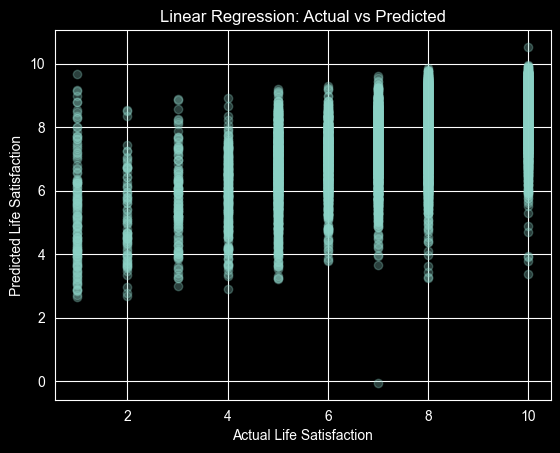

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [11]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

Decision Tree Regressor Results
MAE: 0.9445695499108501
RMSE: 1.2841968448081187
R2: 0.3271392969395499


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_tree
})

comparison.head(10)

,Actual,Predicted
32631,10,8.998155
51733,8,8.286563
93273,6,7.996329
96034,8,8.286563
40798,7,7.558465
101425,6,6.237179
41014,5,8.127233
61208,8,8.286563
46555,10,7.721401
9341,10,8.609033


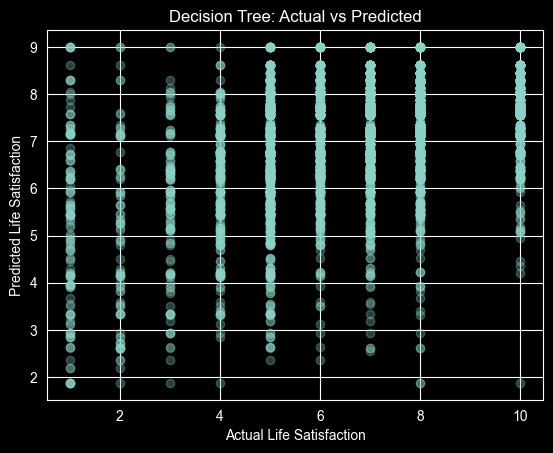

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_tree, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    max_features="sqrt",
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Regressor Results
MAE: 0.9208831787384906
RMSE: 1.2898112808890299
R2: 0.32124301796556776


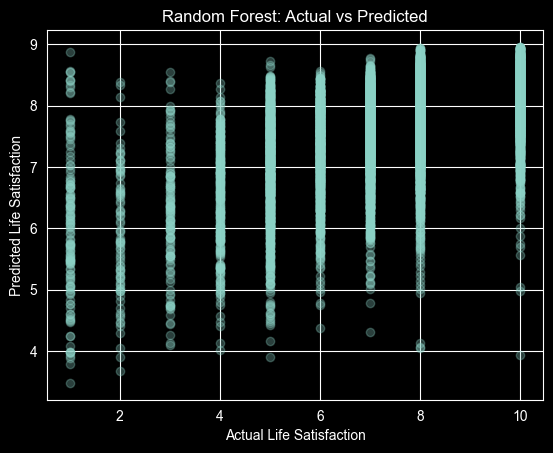

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [9]:
import pandas as pd

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(15)

Mental_health_state_4    0.085274
Mental_health_state_5    0.080515
Gen_health_state_5       0.074261
Health_utility_indx_2    0.068052
Gen_health_state_4       0.054116
Mental_health_state_3    0.051602
Mood_disorder_2          0.046944
Stress_level_4           0.042030
Pain_status_2            0.028251
Sense_belonging_4        0.027262
Anxiety_disorder_2       0.026841
Stress_level_5           0.025153
Marital_status_2         0.022806
Gen_health_state_3       0.022393
Sense_belonging_3        0.021440
dtype: float64

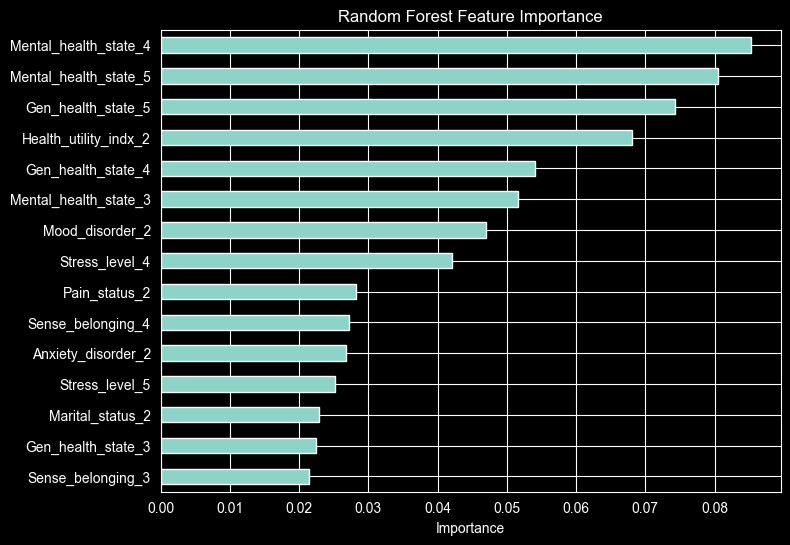

In [17]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

In [10]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

XGBoost Regressor Results
MAE: 0.9006114602088928
RMSE: 1.2226922758114736
R2: 0.3900471329689026


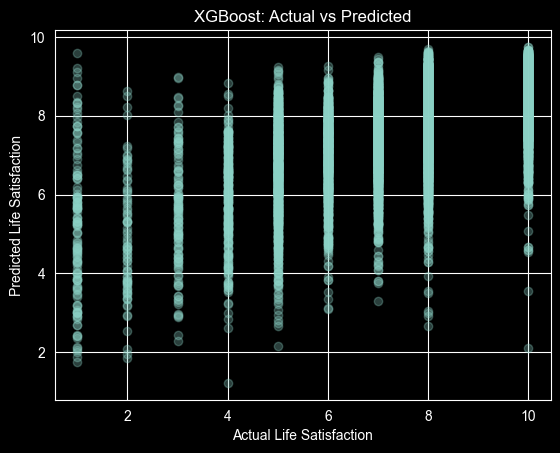

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [15]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

xgb_importance.head(15)

Mental_health_state_4           0.108852
Mental_health_state_5           0.069991
Mental_health_state_3           0.068433
Gen_health_state_5              0.049582
Health_utility_indx_2           0.046390
Gen_health_state_3              0.036412
Gen_health_state_4              0.034122
Mood_disorder_2                 0.031046
Mental_health_state_2           0.025376
Pain_status_2                   0.021831
Stress_level_4                  0.020747
Marital_status_2                0.016732
Mental_health_state__missing    0.015102
Sense_belonging_3               0.014224
Sense_belonging_4               0.013620
dtype: float32

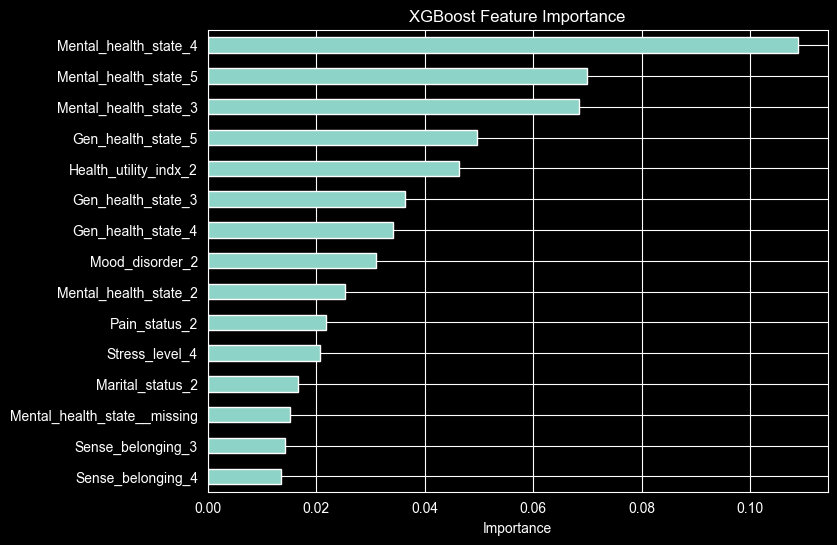

In [16]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()